# Capstone Function 3
You're working on a drug discovery project, testing combinations of three compounds to create a new medicine.\
Each experiment is stored in ```initial_inputs.npy``` as a 3D array, where each row lists the amounts of the three compounds used.  After each experiment, you record the number of adverse reactions, stored in ```initial_outputs.npy``` as a 1D array.\
Your goal is to minimise the side effects, it is framed as a maximisation by optimising a transformed output (e.g. the negative of side effects)

 Input | Output | Goal |
|-------|--------|------|
| 3D Array (15, 3) | 1D Array (15, ) | Maximise |

# Exploratory Data Analysis

In [2]:
# load and view a .npy file
import numpy as np
from matplotlib import pyplot as plt
import sys
# load the .npy file
inputs = np.load("../data/f3/updated_inputs.npy")
outputs = np.load("../data/f3/updated_outputs.npy")
# summarize shape
print(inputs.shape)
print(outputs.shape)

# create a dataframe from inputs and outputs
import pandas as pd
data = pd.DataFrame(inputs, columns=[f'input_{i}' for i in range(inputs.shape[1])])
data['output'] = outputs
print(data.tail(5))

(18, 3)
(18,)
     input_0   input_1   input_2    output
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.999999  0.789473  0.368421 -0.033818
16  0.579462  0.533837  0.014859 -0.072569
17  1.000000  0.669794  0.852827 -0.039418


## Observations
- Outputs are very small numbers.  Engineering intuition tells me that noise may impact these results signficantly

# Gaussian Process with Upper Confidence Bound Acquisition Function
1. Using the code from Module 12, I get rubbish numbers, but Copilot generated code seems to yeild a better mean, but throws an error re: convergence

In [8]:

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Load the dataset provided
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Define the kernel for Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0, 1.0], length_scale_bounds=(1e-2, 1e2))

# Fit Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# Define the search space for the next sample (grid in [0,1]^3)
grid_size = 20  # Smaller grid for 3D to avoid huge computation
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
x3 = np.linspace(0, 1, grid_size)
X_grid = np.array([[a, b, c] for a in x1 for b in x2 for c in x3])

# Predict mean and standard deviation for each point in the grid
mean, std = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound (UCB) acquisition function
kappa = 2.0  # Exploration-exploitation trade-off parameter
ucb = mean + kappa * std

# Select the next input sample as the point with the highest UCB
next_index = np.argmax(ucb)
next_sample = X_grid[next_index]

print("Next input sample based on Upper Confidence Bound (UCB):", next_sample)
print("Predicted mean:", mean[next_index])
print("Predicted std deviation:", std[next_index])
print("UCB value:", ucb[next_index])


Next input sample based on Upper Confidence Bound (UCB): [1. 0. 0.]
Predicted mean: -0.056970964578912243
Predicted std deviation: 0.09506112317865437
UCB value: 0.1331512817783965


/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


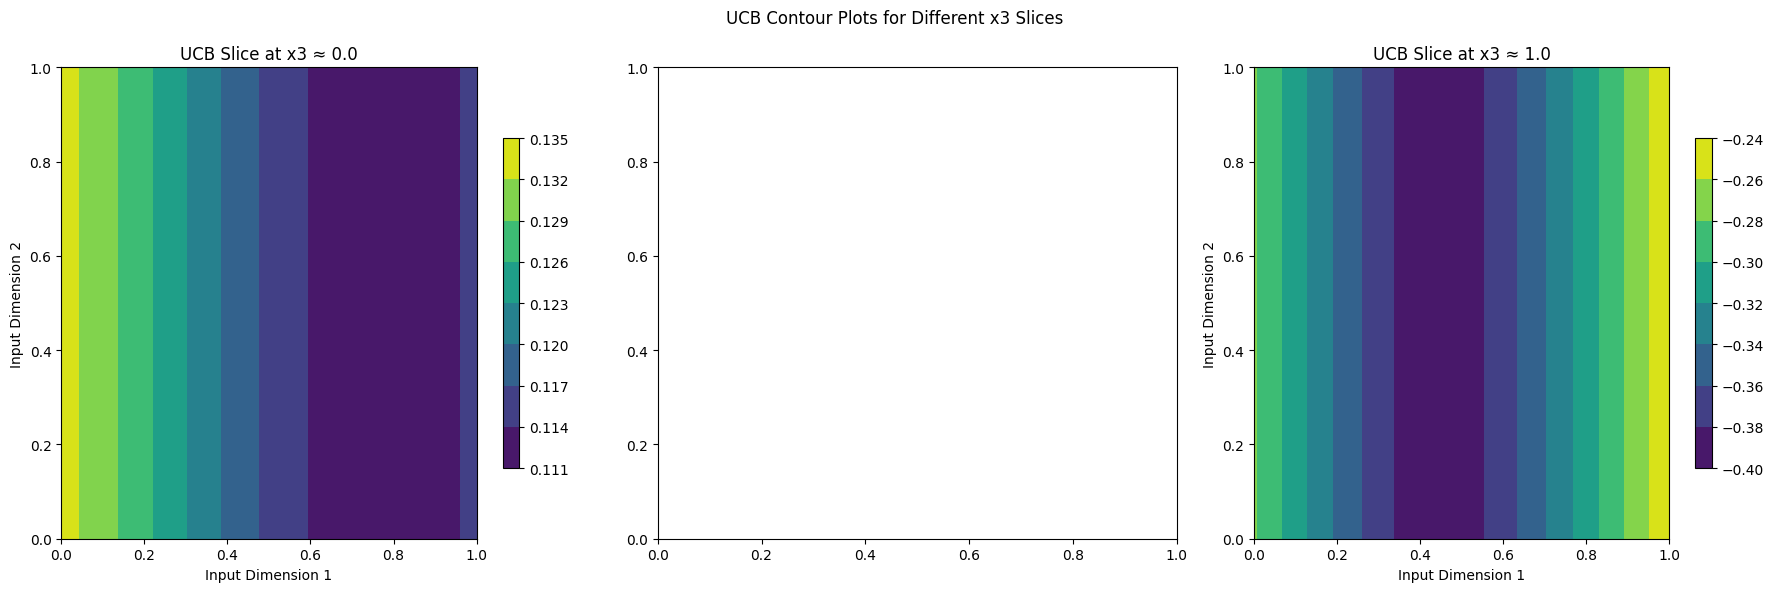

Next input sample based on UCB: [1.         1.         0.86206897]
Predicted mean: -0.03407305249353275
Predicted std deviation: 0.08412798290864688


In [10]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Load the dataset provided
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Define the kernel for Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0, 1.0], length_scale_bounds=(1e-2, 1e2))

# Fit Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# Define the search space for the next sample (grid in [0,1]^3)
grid_size = 30
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
x3 = np.linspace(0, 1, grid_size)
X_grid = np.array([[a, b, c] for a in x1 for b in x2 for c in x3])

# Predict mean and standard deviation for each point in the grid
mean, std = gp.predict(X_grid, return_std=True)

# Compute UCB
kappa = 2.0
ucb = mean + kappa * std

# Select next point
next_index = np.argmax(ucb)
next_sample = X_grid[next_index]

# Visualise UCB slices for fixed x3 values
slice_values = [0.0, 0.5, 1.0]  # slices at these x3 values
fig, axes = plt.subplots(1, len(slice_values), figsize=(18, 6))

for idx, val in enumerate(slice_values):
    # Select points near the slice value
    tolerance = 0.02
    mask = np.abs(X_grid[:, 2] - val) < tolerance
    X_slice = X_grid[mask]
    ucb_slice = ucb[mask]

    # Reshape for contour plot
    if len(ucb_slice) == grid_size * grid_size:
        UCB_surface = ucb_slice.reshape(grid_size, grid_size)
        X1_mesh, X2_mesh = np.meshgrid(x1, x2)

        cs = axes[idx].contourf(X1_mesh, X2_mesh, UCB_surface, cmap='viridis')
        axes[idx].set_title(f'UCB Slice at x3 ≈ {val}')
        axes[idx].set_xlabel('Input Dimension 1')
        axes[idx].set_ylabel('Input Dimension 2')

        # Highlight next sample if in this slice
        if abs(next_sample[2] - val) < tolerance:
            axes[idx].scatter(next_sample[0], next_sample[1], color='red', marker='*', s=150, label='Next Sample')
            axes[idx].legend()

        fig.colorbar(cs, ax=axes[idx], shrink=0.7)

plt.suptitle('UCB Contour Plots for Different x3 Slices')
plt.tight_layout()
plt.show()

print("Next input sample based on UCB:", next_sample)
print("Predicted mean:", mean[next_index])
print("Predicted std deviation:", std[next_index])


# Gaussian Process with PI Acquisition Function
Using the xi value of 0.01

In [9]:

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# Load the dataset provided
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Define the kernel for Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0, 1.0], length_scale_bounds=(1e-2, 1e2))

# Fit Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# Define the search space for the next sample (grid in [0,1]^3)
grid_size = 20  # Smaller grid for 3D to avoid huge computation
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
x3 = np.linspace(0, 1, grid_size)
X_grid = np.array([[a, b, c] for a in x1 for b in x2 for c in x3])

# Predict mean and standard deviation for each point in the grid
mean, std = gp.predict(X_grid, return_std=True)

# Probability of Improvement (PI) acquisition function
best_y = np.max(y)  # For maximisation problem
xi = 0.01  # Small margin for improvement
z = (mean - best_y - xi) / std
pi = norm.cdf(z)

# Select the next input sample as the point with the highest PI
next_index = np.argmax(pi)
next_sample = X_grid[next_index]

print("Next input sample based on Probability of Improvement (PI):", next_sample)
print("Predicted mean:", mean[next_index])
print("Predicted std deviation:", std[next_index])
print("Probability of Improvement:", pi[next_index])



Next input sample based on Probability of Improvement (PI): [1.         0.78947368 0.36842105]
Predicted mean: -0.02122322948990056
Predicted std deviation: 0.02152760327466573
Probability of Improvement: 0.5666251577034901


/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Gaussian Process with EI Acquisition Function

In [ ]:

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# Load the dataset provided
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Define the kernel for Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0, 1.0], length_scale_bounds=(1e-2, 1e2))

# Fit Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# Define the search space for the next sample (grid in [0,1]^3)
grid_size = 20  # Smaller grid for 3D to avoid huge computation
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
x3 = np.linspace(0, 1, grid_size)
X_grid = np.array([[a, b, c] for a in x1 for b in x2 for c in x3])

# Predict mean and standard deviation for each point in the grid
mean, std = gp.predict(X_grid, return_std=True)

# Expected Improvement (EI) acquisition function
best_y = np.max(y)  # For maximisation problem
xi = 0.01  # Small margin for improvement
z = (mean - best_y - xi) / std
ei = (mean - best_y - xi) * norm.cdf(z) + std * norm.pdf(z)

# Select the next input sample as the point with the highest EI
next_index = np.argmax(ei)
next_sample = X_grid[next_index]

print("Next input sample based on Expected Improvement (EI):", next_sample)
print("Predicted mean:", mean[next_index])
print("Predicted std deviation:", std[next_index])
print("Expected Improvement:", ei[next_index])


Next input sample based on Expected Improvement (EI): [1.         1.         0.42105263]
Predicted mean: -0.022527312999003984
Predicted std deviation: 0.06613579072944833
Expected Improvement: 0.027554427992335824


/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Visualisation

# Week 1 Submission
0.999999-0.789473-0.368421

---
---
# Week 2
Try to improve the process:
1. Build a SMBO (Sequential Model Based Optimisation) process to iteratively add new samples as they become available.
2. Visualize the performance - convergence
3. True to improve the various parameters!
4. Review which acquisition function to use

Text(0, 0.5, 'PC2')

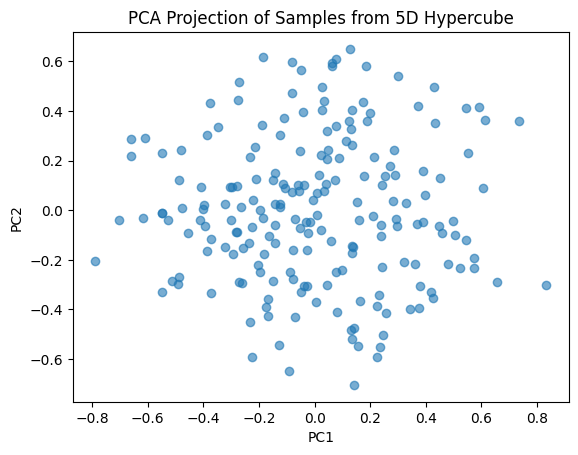

In [5]:

from sklearn.decomposition import PCA

# Example: 5D hypercube
samples = np.random.rand(200, 5)

# Reduce to 2D for visualisation
pca = PCA(n_components=2)
proj = pca.fit_transform(samples)

plt.scatter(proj[:, 0], proj[:, 1], alpha=0.6)
plt.title('PCA Projection of Samples from 5D Hypercube')
plt.xlabel('PC1')
plt.ylabel('PC2')


Suggested new points: [[0.5794624936828521, 0.533837528237233, 0.014859660343738382]]


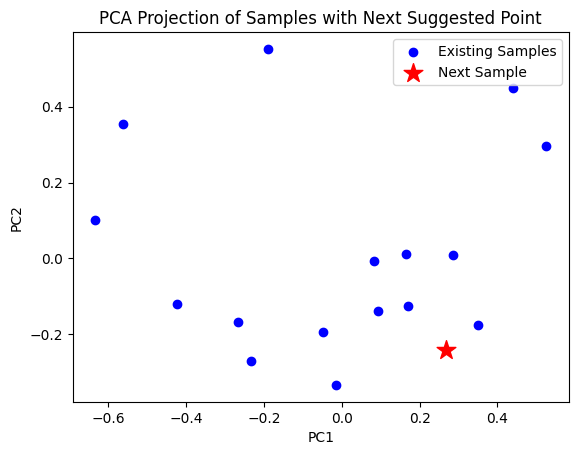

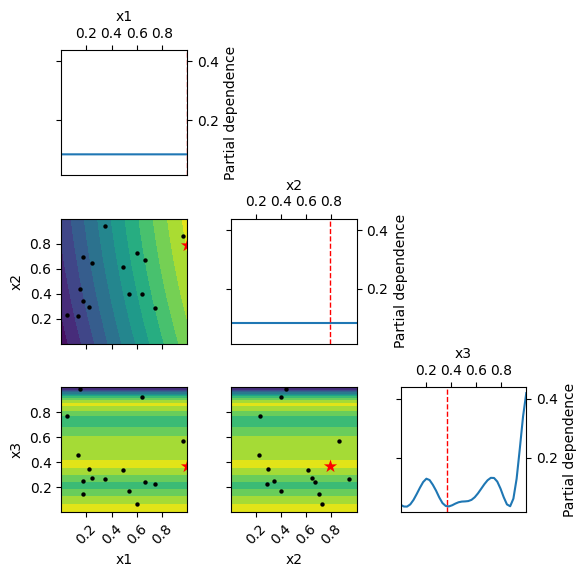

In [9]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="PI", random_state=42)

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation at end of X and y (negate y for maximisation)
X.append([0.999999, 0.789473, 0.368421])
y.append(-0.033817)

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_points = opt.ask(n_points=1)  # propose new point
print("Suggested new points:", next_points)

# Use PCA to plot the next sample in 2D
pca = PCA(n_components=2)
proj = pca.fit_transform(np.array(X + next_points))
plt.scatter(proj[:-1, 0], proj[:-1, 1], c='blue', label='Existing Samples')
plt.scatter(proj[-1, 0], proj[-1, 1], c='red', label='Next Sample', marker='*', s=200)
plt.title('PCA Projection of Samples with Next Suggested Point')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

_ = plot_objective(res)


## Submission
0.579462-0.533837-0.014859

---
---
# Week 3

Suggested new point: 1.000000-0.669794-0.852827


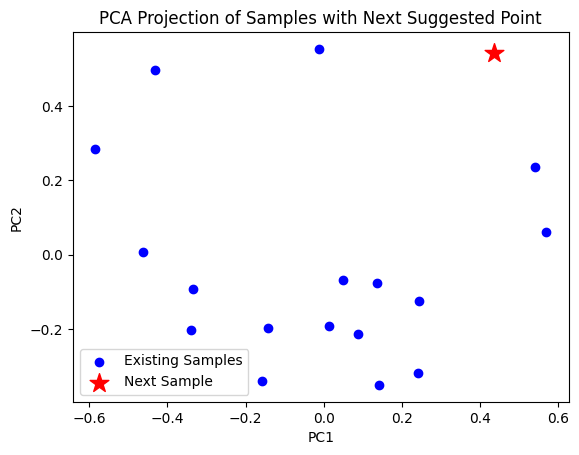

00. X: 0.171525, 0.343917, 0.248737, y:       -0.112122
01. X: 0.242114, 0.644074, 0.272433, y:       -0.087963
02. X: 0.534906, 0.398501, 0.173389, y:       -0.111415
03. X: 0.492581, 0.611593, 0.340176, y:       -0.034835
04. X: 0.134622, 0.219917, 0.458206, y:       -0.048008
05. X: 0.345523, 0.941360, 0.269363, y:       -0.110621
06. X: 0.151837, 0.439991, 0.990882, y:       -0.398926
07. X: 0.645503, 0.397143, 0.919771, y:       -0.113869
08. X: 0.746912, 0.284196, 0.226300, y:       -0.131461
09. X: 0.170477, 0.697032, 0.149169, y:       -0.094190
10. X: 0.220549, 0.297825, 0.343555, y:       -0.046947
11. X: 0.666014, 0.671985, 0.246295, y:       -0.105965
12. X: 0.046809, 0.231360, 0.770618, y:       -0.118048
13. X: 0.600097, 0.725136, 0.066089, y:       -0.036378
14. X: 0.965995, 0.861120, 0.566829, y:       -0.056758
15. X: 0.999999, 0.789473, 0.368421, y:       -0.033817
16. X: 0.579462, 0.533837, 0.014859, y:       -0.072569


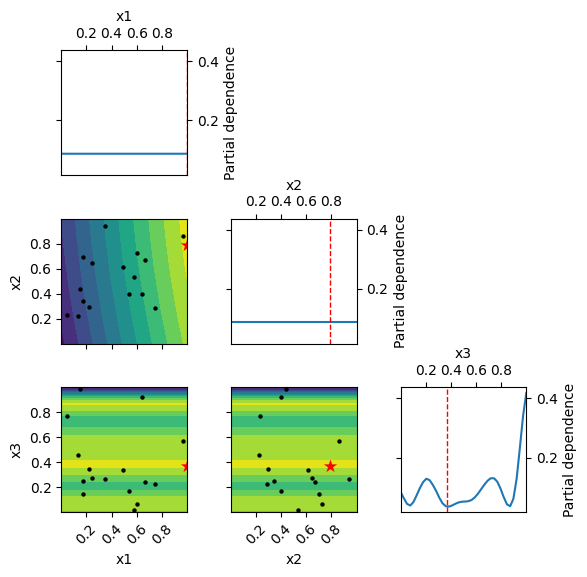

In [ ]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="LCB", random_state=42, acq_func_kwargs={'kappa': 2.0})

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation at end of X and y (negate y for maximisation)
X.append([0.999999, 0.789473, 0.368421])
y.append(-0.033817)

# insert a new observation for week 3
X.append([0.579462, 0.533837, 0.014859])
y.append(-0.072569)

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose new point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}")

# Use PCA to plot the next sample in 2D
pca = PCA(n_components=2)
proj = pca.fit_transform(np.array(X + next_point))
plt.scatter(proj[:-1, 0], proj[:-1, 1], c='blue', label='Existing Samples')
plt.scatter(proj[-1, 0], proj[-1, 1], c='red', label='Next Sample', marker='*', s=200)
plt.title('PCA Projection of Samples with Next Suggested Point')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

_ = plot_objective(res)

# negate all the y values back to original
y = [-val for val in y]

# Print X and y in a formatted way with unpacked coordinates
max_y_index = np.argmax(y)
# Use fixed width for y column (easier to read)
for i in range(len(X)):
    x_str = ", ".join(f"{val:.6f}" for val in X[i])
    
    # Right-align y values in 15 character width
    y_str = f"{y[i]:>15.6f}"
    
    if i == max_y_index:
        print(f"{i:02d}. \033[92mX: {x_str}, y: {y_str}\033[0m")
    else:
        print(f"{i:02d}. X: {x_str}, y: {y_str}")

## Week 4:

Sample: 1.000000-0.669794-0.852827

### Hyperparameter Selection
Convergence has slowed, encourage a balance of exploitation and exploration

- Acquisition Function: EI
- xi = 0.05

Suggested new point: 0.879425-0.035487-0.649144


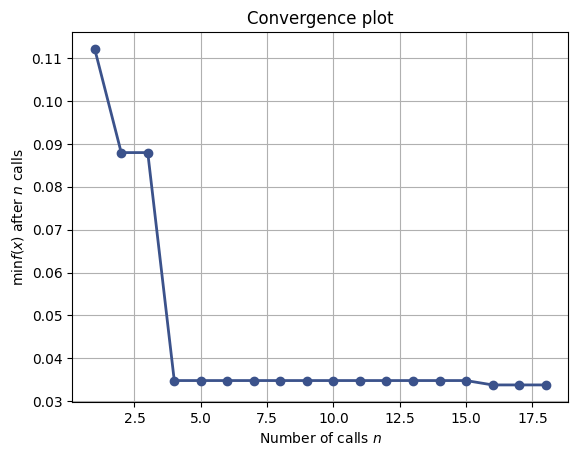

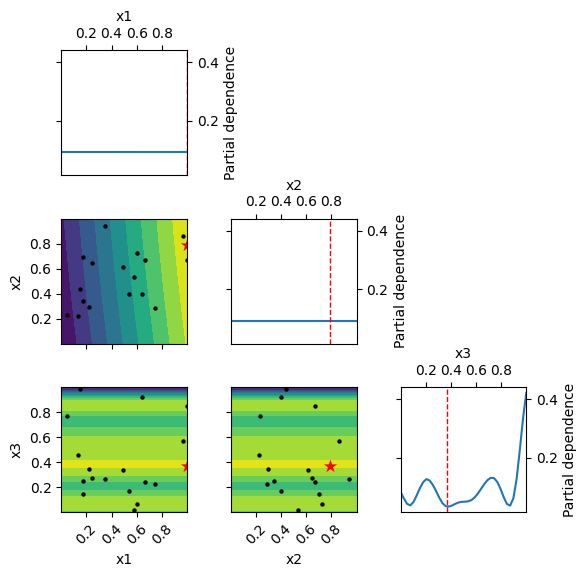

In [8]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "EI"
random_state = 42
acq_func_kwargs = {'xi': 0.05}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data (10 samples)
X = np.load("../data/f3/updated_inputs.npy").tolist()
y = np.load("../data/f3/updated_outputs.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)




## Week 5

### Hyperparameter Selection - Last Week
Convergence has slowed, encourage a balance of exploitation and exploration

- Acquisition Function: EI
- xi = 0.05

### Observation

Suggested new point: 0.816399-0.913657-0.514870


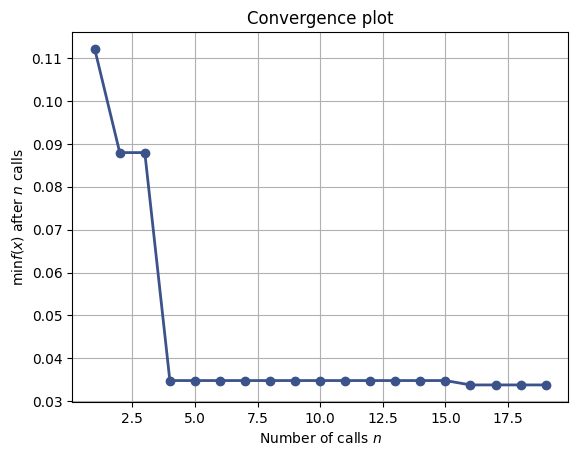

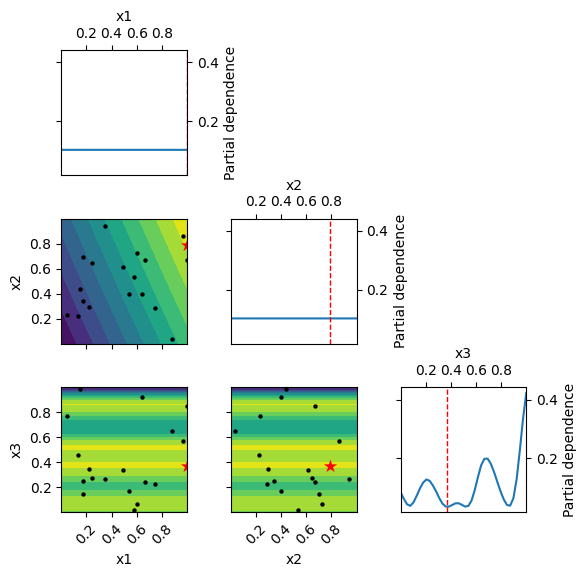

In [9]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "EI"
random_state = 42
acq_func_kwargs = {'xi': 0.05}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data (10 samples)
X = np.load("../data/f3/updated_inputs - Week 4.npy").tolist()
y = np.load("../data/f3/updated_outputs - Week 4.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)


